# Fase 2 — Modelo Entidad-Relación
**Proyecto Final — Gestión de Datos (UAX 2025/2026)**

Documentación formal del modelo ER de la base de datos operacional `saleshealth`.
El schema se extrae directamente de PostgreSQL para garantizar que el diagrama
refleja la realidad de los datos, no suposiciones.

---

## Configuración

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from sqlalchemy import create_engine, text
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

PROJECT_ROOT = Path(r'C:\Users\Propietario\Desktop\segundo cuatri\gestion de datos\trabajo final gd')
FIGURES_DIR  = PROJECT_ROOT / 'reports' / 'figures'
DOCS_DIR     = PROJECT_ROOT / 'docs' / 'diagramas'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
DOCS_DIR.mkdir(parents=True, exist_ok=True)

PALETA = {
    'ERP'       : '#2C6FBF',
    'CRM'       : '#27A06B',
    'Logistica' : '#E07B2A',
    'Postventa' : '#8B4BB8'
}

SISTEMAS = {
    'ERP'       : ['product', 'central_product', 'brand', 'category',
                   'sale', 'sale_item', 'offer', 'product_offer', 'store', 'inventory'],
    'CRM'       : ['customer', 'city_zone'],
    'Logistica' : ['warehouse', 'warehouse_location', 'central_inventory'],
    'Postventa' : ['return_item', 'return_reason']
}

DB_USER     = 'postgres'
DB_PASSWORD = 'pimpum.postgre'
DB_HOST     = 'localhost'
DB_PORT     = '5432'
DB_NAME     = 'saleshealth'

engine = create_engine(
    f'postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}'
)

def query(sql, params=None):
    with engine.connect() as conn:
        return pd.read_sql_query(text(sql), conn, params=params)

print('Configuracion lista.')

Configuracion lista.


---
## 1. Extracción del schema real desde PostgreSQL

In [2]:
# ── Columnas de todas las tablas ──────────────────────────────────────────────
df_columnas = query("""
    SELECT
        c.table_name,
        c.column_name,
        c.data_type,
        c.is_nullable,
        c.ordinal_position,
        CASE WHEN pk.column_name IS NOT NULL THEN TRUE ELSE FALSE END AS is_pk,
        CASE WHEN fk.column_name IS NOT NULL THEN TRUE ELSE FALSE END AS is_fk,
        fk.foreign_table_name,
        fk.foreign_column_name
    FROM information_schema.columns c
    LEFT JOIN (
        SELECT ku.table_name, ku.column_name
        FROM information_schema.table_constraints tc
        JOIN information_schema.key_column_usage ku
          ON tc.constraint_name = ku.constraint_name
        WHERE tc.constraint_type = 'PRIMARY KEY'
          AND tc.table_schema = 'public'
    ) pk ON pk.table_name = c.table_name AND pk.column_name = c.column_name
    LEFT JOIN (
        SELECT
            kcu.table_name,
            kcu.column_name,
            ccu.table_name  AS foreign_table_name,
            ccu.column_name AS foreign_column_name
        FROM information_schema.table_constraints tc
        JOIN information_schema.key_column_usage kcu
          ON tc.constraint_name = kcu.constraint_name
        JOIN information_schema.constraint_column_usage ccu
          ON ccu.constraint_name = tc.constraint_name
        WHERE tc.constraint_type = 'FOREIGN KEY'
          AND tc.table_schema = 'public'
    ) fk ON fk.table_name = c.table_name AND fk.column_name = c.column_name
    WHERE c.table_schema = 'public'
    ORDER BY c.table_name, c.ordinal_position
""")

# ── Relaciones FK ─────────────────────────────────────────────────────────────
df_fks = query("""
    SELECT
        kcu.table_name      AS tabla_origen,
        kcu.column_name     AS columna_fk,
        ccu.table_name      AS tabla_destino,
        ccu.column_name     AS columna_pk,
        tc.constraint_name
    FROM information_schema.table_constraints tc
    JOIN information_schema.key_column_usage kcu
      ON tc.constraint_name = kcu.constraint_name
    JOIN information_schema.constraint_column_usage ccu
      ON ccu.constraint_name = tc.constraint_name
    WHERE tc.constraint_type = 'FOREIGN KEY'
      AND tc.table_schema = 'public'
    ORDER BY kcu.table_name, kcu.column_name
""")

tablas = df_columnas['table_name'].unique().tolist()

print(f'Tablas encontradas    : {len(tablas)}')
print(f'Columnas totales      : {len(df_columnas)}')
print(f'Relaciones FK         : {len(df_fks)}')
print(f'\nTablas: {sorted(tablas)}')

Tablas encontradas    : 17
Columnas totales      : 96
Relaciones FK         : 16

Tablas: ['brand', 'category', 'central_inventory', 'central_product', 'city_zone', 'customer', 'inventory', 'offer', 'product', 'product_offer', 'return_item', 'return_reason', 'sale', 'sale_item', 'store', 'warehouse', 'warehouse_location']


In [3]:
# ── Detalle de columnas por tabla ─────────────────────────────────────────────
print('=' * 72)
print('  SCHEMA COMPLETO — saleshealth.public')
print('=' * 72)

for sistema, tablas_s in SISTEMAS.items():
    print(f'\n  [{sistema}]')
    for tabla in tablas_s:
        cols = df_columnas[df_columnas['table_name'] == tabla]
        n_registros = int(query(f'SELECT COUNT(*) AS n FROM {tabla}')['n'].iloc[0])
        print(f'\n  {tabla}  ({n_registros:,} registros)')
        print(f'  {"COLUMNA":<25} {"TIPO":<20} {"NULO":>6}  {"CLAVE"}')
        print('  ' + '-' * 60)
        for _, row in cols.iterrows():
            clave = ''
            if row['is_pk']: clave = 'PK'
            elif row['is_fk']: clave = f'FK → {row["foreign_table_name"]}.{row["foreign_column_name"]}'
            nulo = 'YES' if row['is_nullable'] == 'YES' else 'NO'
            print(f'  {row["column_name"]:<25} {row["data_type"]:<20} {nulo:>6}  {clave}')

print(f'\n{"="*72}')

  SCHEMA COMPLETO — saleshealth.public

  [ERP]

  product  (50 registros)
  COLUMNA                   TIPO                   NULO  CLAVE
  ------------------------------------------------------------
  product_id                integer                  NO  PK
  name                      character varying        NO  
  category                  character varying       YES  
  manufacturer              character varying       YES  
  price                     numeric                  NO  
  created_at                timestamp without time zone    YES  

  central_product  (50 registros)
  COLUMNA                   TIPO                   NULO  CLAVE
  ------------------------------------------------------------
  product_id                integer                  NO  PK
  name                      character varying        NO  
  category_id               integer                 YES  FK → category.category_id
  brand_id                  integer                 YES  FK → brand.brand_id
  s

---
## 2. Generación del código DBML

In [4]:
# ── Generar DBML desde el schema real ────────────────────────────────────────
# DBML es el formato de dbdiagram.io — permite generar diagramas ER
# profesionales pegando este texto en https://dbdiagram.io/d

TYPE_MAP = {
    'integer'                    : 'integer',
    'numeric'                    : 'decimal',
    'character varying'          : 'varchar',
    'text'                       : 'text',
    'boolean'                    : 'boolean',
    'date'                       : 'date',
    'timestamp without time zone': 'timestamp',
    'timestamp with time zone'   : 'timestamptz',
}

def tipo_dbml(pg_type):
    return TYPE_MAP.get(pg_type, pg_type)

lineas = ['// Modelo ER — saleshealth operacional',
          '// Generado automáticamente desde PostgreSQL',
          '// Importar en https://dbdiagram.io/d',
          '']

# Agrupar por sistema con comentario
for sistema, tablas_s in SISTEMAS.items():
    lineas.append(f'// ── {sistema} ──────────────────────────────────────────')
    for tabla in tablas_s:
        cols = df_columnas[df_columnas['table_name'] == tabla]
        lineas.append(f'Table {tabla} {{')
        for _, row in cols.iterrows():
            tipo = tipo_dbml(row['data_type'])
            notas = []
            if row['is_pk']:
                notas.append('pk')
            if row['is_nullable'] == 'NO' and not row['is_pk']:
                notas.append('not null')
            nota_str = f' [{', '.join(notas)}]' if notas else ''
            lineas.append(f'  {row["column_name"]} {tipo}{nota_str}')
        lineas.append('}')
        lineas.append('')

# Relaciones
lineas.append('// ── Relaciones ─────────────────────────────────────────────')
for _, row in df_fks.iterrows():
    lineas.append(
        f'Ref: {row["tabla_origen"]}.{row["columna_fk"]} > '
        f'{row["tabla_destino"]}.{row["columna_pk"]}'
    )

DBML = '\n'.join(lineas)

# Guardar en docs/diagramas/
dbml_path = DOCS_DIR / 'er_operacional.dbml'
dbml_path.write_text(DBML, encoding='utf-8')

print(DBML)
print(f'\n✅ DBML guardado en: {dbml_path}')

// Modelo ER — saleshealth operacional
// Generado automáticamente desde PostgreSQL
// Importar en https://dbdiagram.io/d

// ── ERP ──────────────────────────────────────────
Table product {
  product_id integer [pk]
  name varchar [not null]
  category varchar
  manufacturer varchar
  price decimal [not null]
  created_at timestamp
}

Table central_product {
  product_id integer [pk]
  name varchar [not null]
  category_id integer
  brand_id integer
  sku varchar
  barcode varchar
  unit_cost decimal
  unit_price decimal
}

Table brand {
  brand_id integer [pk]
  name varchar [not null]
  country varchar
  website varchar
}

Table category {
  category_id integer [pk]
  name varchar [not null]
  description text
}

Table sale {
  sale_id integer [pk]
  customer_id integer
  store_id integer
  sale_date timestamp [not null]
  total decimal
}

Table sale_item {
  sale_item_id integer [pk]
  sale_id integer
  product_id integer
  quantity integer [not null]
  unit_price decimal [not nul

---
## 3. Visualización del grafo de relaciones en el notebook

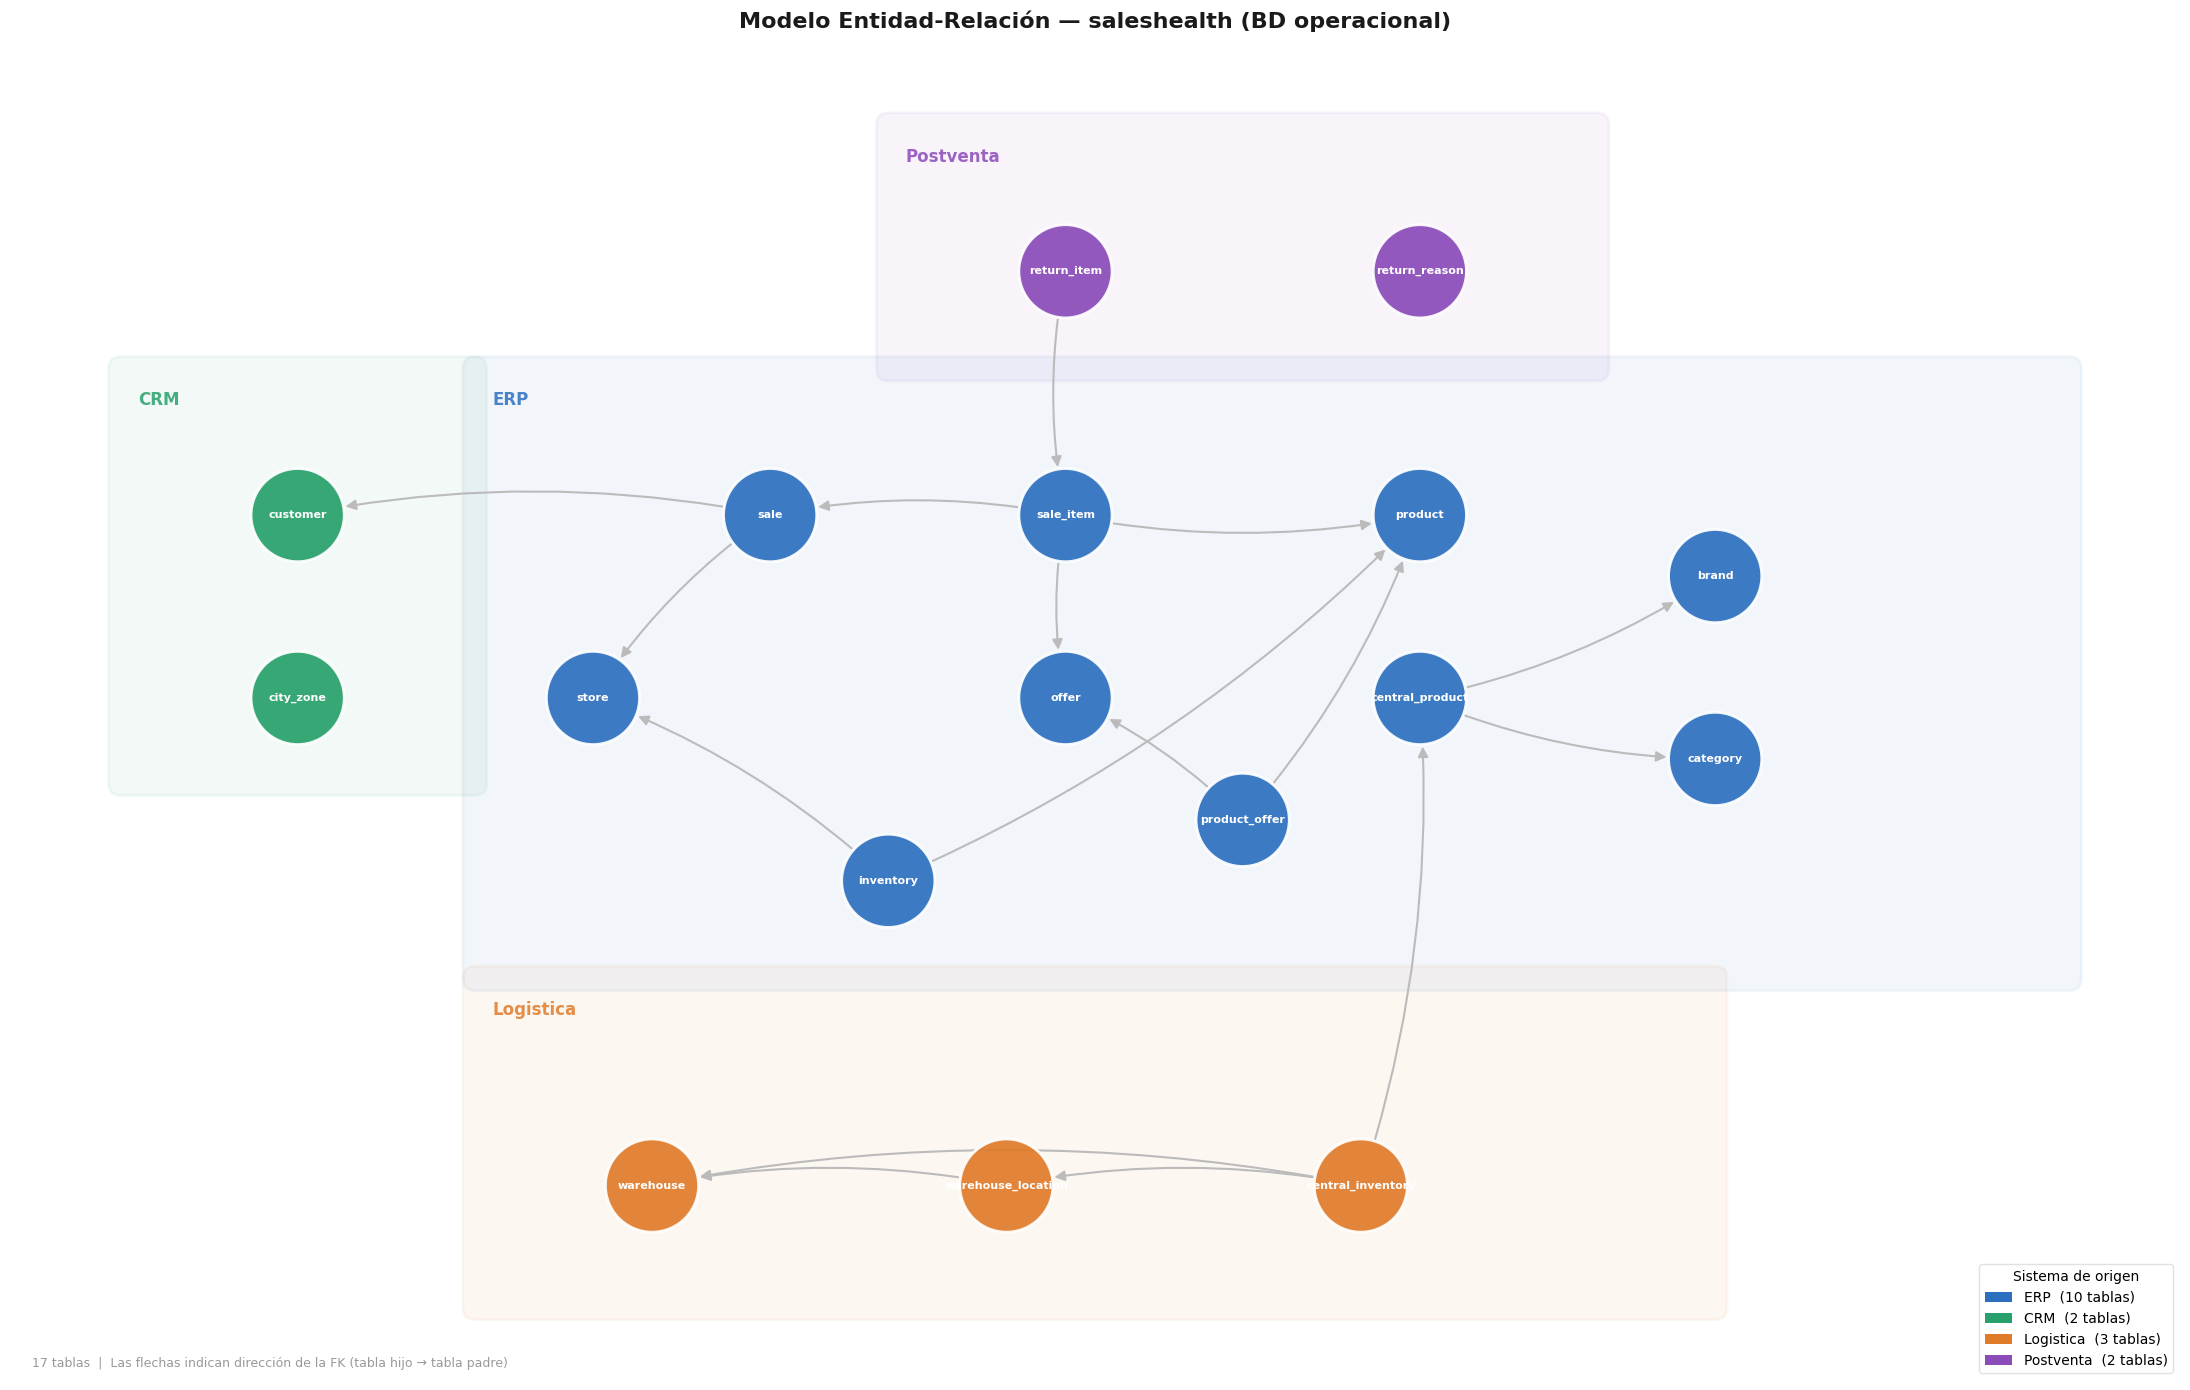


✅ Diagrama ER guardado en:
   C:\Users\Propietario\Desktop\segundo cuatri\gestion de datos\trabajo final gd\reports\figures\15_er_operacional.png
   C:\Users\Propietario\Desktop\segundo cuatri\gestion de datos\trabajo final gd\docs\diagramas\er_operacional.png


In [11]:
# ── Grafo de relaciones coloreado por sistema ─────────────────────────────────
G = nx.DiGraph()
tabla_a_sistema = {t: s for s, ts in SISTEMAS.items() for t in ts}
for tabla, sistema in tabla_a_sistema.items():
    G.add_node(tabla, sistema=sistema)
for _, row in df_fks.iterrows():
    G.add_edge(row['tabla_origen'], row['tabla_destino'],
               label=row['columna_fk'])

POS = {
    # ERP
    'sale'            : (0,    4),
    'sale_item'       : (2.5,  4),
    'product'         : (5.5,  4),
    'central_product' : (5.5,  2.5),
    'brand'           : (8.0,  3.5),
    'category'        : (8.0,  2.0),
    'offer'           : (2.5,  2.5),
    'product_offer'   : (4.0,  1.5),
    'store'           : (-1.5, 2.5),
    'inventory'       : (1.0,  1.0),
    # CRM
    'customer'        : (-4.0, 4.0),
    'city_zone'       : (-4.0, 2.5),
    # Logistica
    'warehouse'       : (-1.0, -1.5),
    'warehouse_location': (2.0, -1.5),
    'central_inventory' : (5.0, -1.5),
    # Postventa
    'return_item'     : (2.5,  6.0),
    'return_reason'   : (5.5,  6.0),
}

node_colors = [PALETA.get(tabla_a_sistema.get(n, ''), '#AAAAAA') for n in G.nodes()]

fig, ax = plt.subplots(figsize=(22, 14))
fig.patch.set_facecolor('white')
ax.set_facecolor('#FAFAFA')

nx.draw_networkx_edges(
    G, POS, ax=ax,
    edge_color='#BBBBBB', arrows=True, arrowsize=15,
    arrowstyle='-|>', connectionstyle='arc3,rad=0.1',
    width=1.5, min_source_margin=35, min_target_margin=35
)
nx.draw_networkx_nodes(
    G, POS, ax=ax,
    node_color=node_colors, node_size=4500,
    alpha=0.92, linewidths=2, edgecolors='white'
)
nx.draw_networkx_labels(
    G, POS, ax=ax,
    font_size=8, font_color='white', font_weight='bold'
)

grupos = {
    'ERP'       : {'x': (-2.5, 11.0), 'y': (0.2,  5.2), 'color': PALETA['ERP']},
    'CRM'       : {'x': (-5.5, -2.5), 'y': (1.8,  5.2), 'color': PALETA['CRM']},
    'Logistica' : {'x': (-2.5, 8.0),  'y': (-2.5, 0.2), 'color': PALETA['Logistica']},
    'Postventa' : {'x': (1.0,  7.0),  'y': (5.2,  7.2), 'color': PALETA['Postventa']},
}

for sistema, bounds in grupos.items():
    x0, x1 = bounds['x']
    y0, y1 = bounds['y']
    rect = mpatches.FancyBboxPatch(
        (x0, y0), x1 - x0, y1 - y0,
        boxstyle='round,pad=0.1', linewidth=2,
        edgecolor=bounds['color'], facecolor=bounds['color'],
        alpha=0.06, zorder=0
    )
    ax.add_patch(rect)
    ax.text(x0 + 0.15, y1 - 0.3, sistema,
            fontsize=12, fontweight='bold',
            color=bounds['color'], alpha=0.85)

legend_elements = [
    mpatches.Patch(facecolor=PALETA[s],
                   label=f'{s}  ({len(SISTEMAS[s])} tablas)')
    for s in PALETA
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10,
          frameon=True, framealpha=0.95, edgecolor='#E0E0E0',
          title='Sistema de origen', title_fontsize=10)

ax.set_title('Modelo Entidad-Relación — saleshealth (BD operacional)',
             fontsize=16, fontweight='bold', color='#1A1A1A', pad=18)
ax.text(0.01, 0.01,
        '17 tablas  |  Las flechas indican dirección de la FK (tabla hijo → tabla padre)',
        transform=ax.transAxes, fontsize=9, color='#999999')

ax.axis('off')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '15_er_operacional.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.savefig(DOCS_DIR / 'er_operacional.png', dpi=200,
            bbox_inches='tight', facecolor='white')
plt.show()

print(f'\n✅ Diagrama ER guardado en:')
print(f'   {FIGURES_DIR / "15_er_operacional.png"}')
print(f'   {DOCS_DIR / "er_operacional.png"}')

---
## 4. Instrucciones para dbdiagram.io

Para obtener el diagrama ER profesional de alta calidad:

1. Abre [https://dbdiagram.io/d](https://dbdiagram.io/d)
2. Borra el contenido de ejemplo del panel izquierdo
3. Pega el contenido del archivo `docs/diagramas/er_operacional.dbml`
4. El diagrama se genera automáticamente en el panel derecho
5. Exporta como PNG o PDF desde el menú **Export**
6. Guarda el PNG exportado en `docs/diagramas/er_operacional_dbdiagram.png`

> El archivo DBML ya está guardado en `docs/diagramas/er_operacional.dbml`

In [12]:
# ── Resumen del modelo ER ─────────────────────────────────────────────────────
print('=' * 62)
print('  RESUMEN DEL MODELO ER — saleshealth')
print('=' * 62)

for sistema, tablas_s in SISTEMAS.items():
    total_cols = sum(
        len(df_columnas[df_columnas['table_name'] == t])
        for t in tablas_s
    )
    fks_sistema = len(df_fks[df_fks['tabla_origen'].isin(tablas_s)])
    print(f'\n  {sistema}')
    print(f'  Tablas    : {len(tablas_s)}')
    print(f'  Columnas  : {total_cols}')
    print(f'  FKs       : {fks_sistema}')
    print(f'  Tablas    : {", ".join(tablas_s)}')

print(f'\n{"="*62}')
print(f'  TOTAL  |  {len([t for ts in SISTEMAS.values() for t in ts])} tablas  |  '
      f'{len(df_columnas)} columnas  |  {len(df_fks)} FKs')
print('=' * 62)
print('\nFase 2 — Modelo ER completada.')
print('Entregable guardado en: docs/diagramas/er_operacional.dbml')
print('                        docs/diagramas/er_operacional.png')

  RESUMEN DEL MODELO ER — saleshealth

  ERP
  Tablas    : 10
  Columnas  : 54
  FKs       : 11
  Tablas    : product, central_product, brand, category, sale, sale_item, offer, product_offer, store, inventory

  CRM
  Tablas    : 2
  Columnas  : 13
  FKs       : 0
  Tablas    : customer, city_zone

  Logistica
  Tablas    : 3
  Columnas  : 21
  FKs       : 4
  Tablas    : warehouse, warehouse_location, central_inventory

  Postventa
  Tablas    : 2
  Columnas  : 8
  FKs       : 1
  Tablas    : return_item, return_reason

  TOTAL  |  17 tablas  |  96 columnas  |  16 FKs

Fase 2 — Modelo ER completada.
Entregable guardado en: docs/diagramas/er_operacional.dbml
                        docs/diagramas/er_operacional.png
